### Análise de Sazonalidade no Tribunal Criminal de São Francisco
#### Existe algum padrão de aumento ou queda no número de processos criminais dependendo do mês do ano?

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

url_dataset = "hf://datasets/jamiequint/sf_criminal_court/cases.parquet"
df_analise = pd.read_parquet(url_dataset)
df_analise.head()

,case_number,case_id,defendant_name,filed_date,scraped_at
0,CRI25000001,4161165,CHANTAIL L MYLES,2025-01-02,2026-03-20T22:52:53.372069
1,CRI25000005,4161163,DAJCHA JNALASHAY LANDERS,2025-02-28,2026-03-20T22:57:56.233258
2,CRI25000007,4161183,JOHN MARSHALL THORNTON,NaN,2026-03-20T22:58:17.392932
3,CRI25000008,4161184,CATHERINE MICHELLE WHITE,2025-01-06,2026-03-20T22:58:43.779784
4,CRI25000009,4161185,IDRISSA O SOW,NaN,2026-03-20T22:58:50.308604


In [14]:
df_analise['filed_date'] = pd.to_datetime(df_analise['filed_date'], errors='coerce')

linhas_antes = len(df_analise)
df_analise = df_analise.dropna(subset=['filed_date'])
linhas_depois = len(df_analise)
print(f"Linhas sem data removidas: {linhas_antes - linhas_depois}")

df_analise['mes_abertura'] = df_analise['filed_date'].dt.month
df_analise['ano_abertura'] = df_analise['filed_date'].dt.year

df_analise[['case_number', 'filed_date', 'mes_abertura', 'ano_abertura']].head()

Linhas sem data removidas: 51984


,case_number,filed_date,mes_abertura,ano_abertura
0,CRI25000001,2025-01-02,1,2025
1,CRI25000005,2025-02-28,2,2025
3,CRI25000008,2025-01-06,1,2025
7,CRI25000012,2025-01-03,1,2025
9,CRI25000014,2025-01-03,1,2025


In [15]:
casos_por_mes_total = df_analise.groupby('mes_abertura')['case_number'].count()

casos_por_ano_mes = df_analise.groupby(['ano_abertura', 'mes_abertura'])['case_number'].count().reset_index()
casos_por_ano_mes.rename(columns={'case_number': 'total_casos'}, inplace=True)

anos_completos = casos_por_ano_mes['ano_abertura'].value_counts()
anos_validos = anos_completos[anos_completos == 12].index
casos_por_ano_mes = casos_por_ano_mes[casos_por_ano_mes['ano_abertura'].isin(anos_validos)]

print("Agregações concluídas.")

Agregações concluídas.


/tmp/ipykernel_74765/879164036.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(dados_boxplot, labels=meses_labels, patch_artist=True, boxprops=dict(facecolor='lightgreen'))


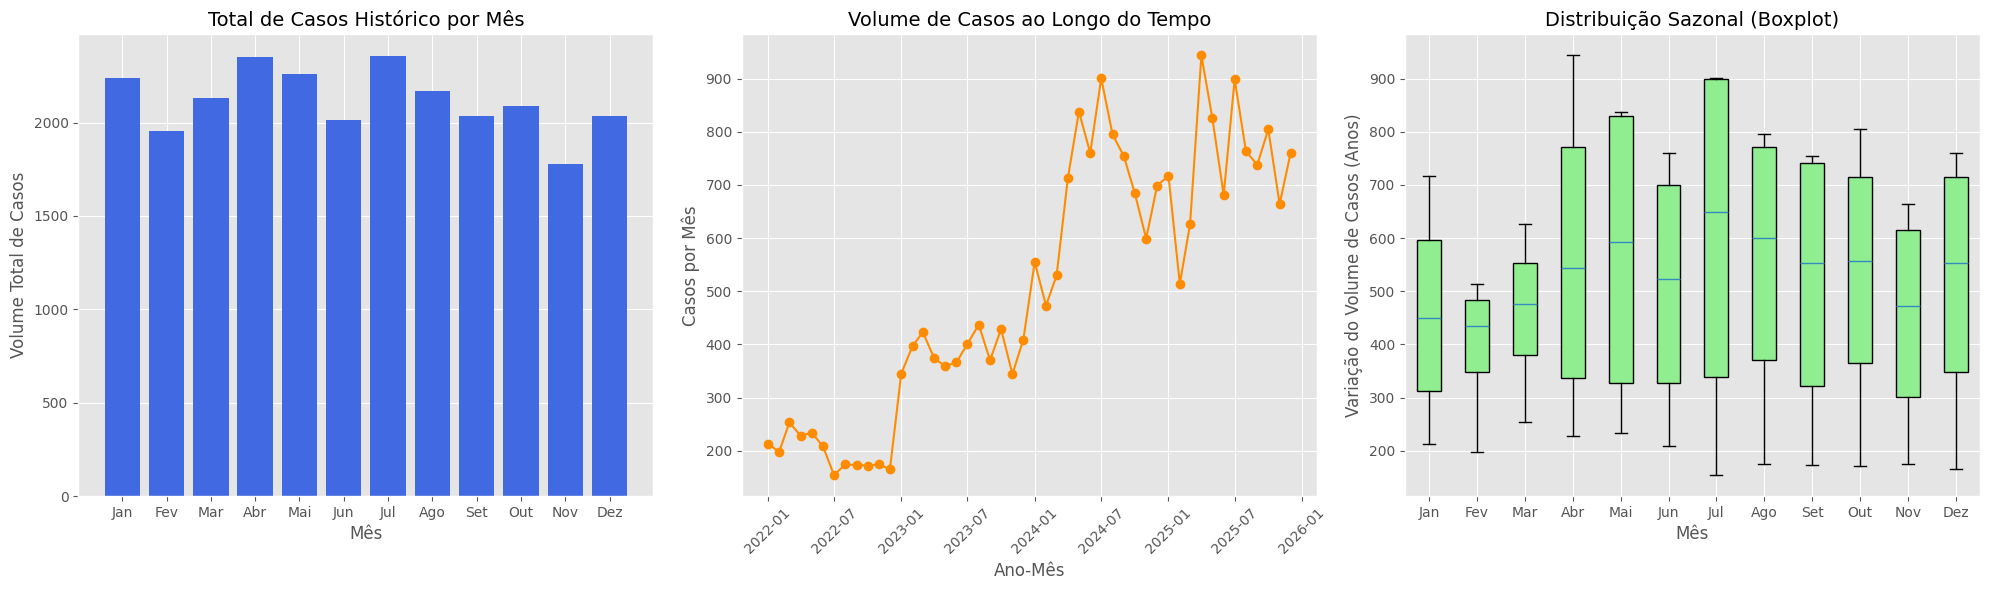

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
meses_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

axes[0].bar(casos_por_mes_total.index, casos_por_mes_total.values, color='royalblue')
axes[0].set_title('Total de Casos Histórico por Mês', fontsize=14)
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Volume Total de Casos')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(meses_labels)

casos_por_ano_mes['data_plot'] = pd.to_datetime(
    casos_por_ano_mes['ano_abertura'].astype(str) + '-' + casos_por_ano_mes['mes_abertura'].astype(str) + '-01'
)
casos_por_ano_mes = casos_por_ano_mes.sort_values('data_plot')

axes[1].plot(casos_por_ano_mes['data_plot'], casos_por_ano_mes['total_casos'], marker='o', color='darkorange')
axes[1].set_title('Volume de Casos ao Longo do Tempo', fontsize=14)
axes[1].set_xlabel('Ano-Mês')
axes[1].set_ylabel('Casos por Mês')
axes[1].tick_params(axis='x', rotation=45)

dados_boxplot = [casos_por_ano_mes[casos_por_ano_mes['mes_abertura'] == i]['total_casos'].values for i in range(1, 13)]

axes[2].boxplot(dados_boxplot, labels=meses_labels, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[2].set_title('Distribuição Sazonal (Boxplot)', fontsize=14)
axes[2].set_xlabel('Mês')
axes[2].set_ylabel('Variação do Volume de Casos (Anos)')

plt.tight_layout()
plt.show()

- Os meses de Fevereiro e Novembro apresentam os menores volumes totais (Gráfico 1) e também as menores variâncias e medianas no Boxplot.
- Meses como Abril e Julho concentram o maior volume histórico, porém, o Boxplot indica que o comportamento não é estável todos os anos; os números foram puxados para cima por eventos atípicos recentes.
- O gráfico de linhas (Gráfico 2) mostra uma explosão estrutural. O volume sai de um patamar baixo e estável em 2022 e inflama violentamente a partir do final de 2023, mantendo extrema volatilidade ao longo de 2024 e 2025.